Using device: cpu
Observations Shape: (6, 64, 64, 3)
Actions Shape: (6,)
Terminals shape: (6,)
VAE Trainable parameters: 4,446,915
RNN Trainable parameters: 1,517,190
Generating VAE reconstructions...
Generating dream sequence...


100%|██████████| 3/3 [00:00<00:00, 42.35it/s]


Creating animation...


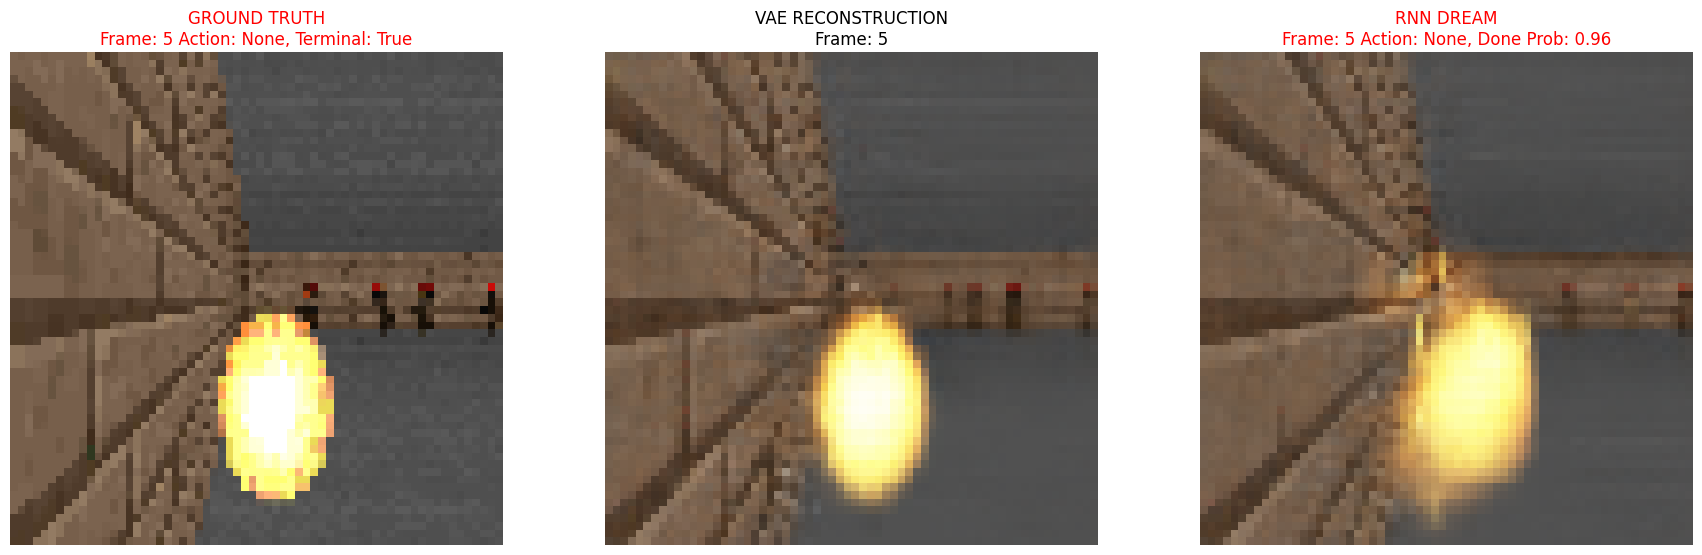

In [ ]:
import numpy as np
import torch
import argparse
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import HTML
import sys
from tqdm import tqdm
sys.path.append('..')
from modules.mdn_rnn import MDN_RNN
from modules.vae import VAE
import os

def _sample_from_mdn(pi_logits, mu, sigma_logits, temperature=1.0):
    """Samples a latent vector from the MDN output with temperature."""
    if temperature <= 0:
        print(f'[WARN] Temperature was <= 0, setting it to 1e-8')
        temperature = 1e-8

    pi = torch.softmax(pi_logits / temperature, dim=-1)
    sigma = torch.exp(sigma_logits)
    mixture = torch.distributions.Categorical(probs=pi)
    k = mixture.sample()

    # Sample from chosen Gaussian
    mu_k = mu[k]
    sigma_k = sigma[k]
    z_next = torch.normal(mu_k, sigma_k)

    return z_next.unsqueeze(0)

class WorldModel:
    """
    A class that encapsulates the VAE, RNN, and the logic to generate sequences.
    """
    def __init__(self, vae_path, rnn_path, latent_dim, vae_inverted, device='cpu'):
        self.device = device
        
        # Load VAE
        self.vae = VAE(latent_dim=latent_dim, inverted_colors=vae_inverted).to(self.device)
        self.vae.load_state_dict(torch.load(vae_path, map_location=device))
        self.vae.eval()
        vae_trainable_params = sum(p.numel() for p in self.vae.parameters() if p.requires_grad)
        print(f"VAE Trainable parameters: {vae_trainable_params:,}")

        # Load RNN
        self.rnn = MDN_RNN(
            latent_dim=latent_dim, 
            action_dim=1, 
            hidden_size=512, 
            n_gaussians=5, 
            num_layers=1
        ).to(self.device)

        self.rnn.load_state_dict(torch.load(rnn_path, map_location=device))
        self.rnn.eval()
        rnn_trainable_params = sum(p.numel() for p in self.rnn.parameters() if p.requires_grad)
        print(f"RNN Trainable parameters: {rnn_trainable_params:,}")

    def reconstruct_sequence(self, observations):
        """Encodes and decodes a sequence of observations using the VAE."""
        with torch.no_grad():
            obs_tensor = torch.tensor(observations / 255.0, dtype=torch.float32).permute(0, 3, 1, 2).to(self.device)
            recon_x, _, _, _ = self.vae(obs_tensor)
            return recon_x.permute(0, 2, 3, 1).cpu().numpy()

    def generate_dream_sequence(self, initial_frames, actions_for_dream, temperature=1.0):
        """
        Generates a "dream" sequence using the RNN, starting from a sequence of initial frames.
        """
        num_context_frames = len(initial_frames)
        num_dream_frames = len(actions_for_dream) - num_context_frames + 1
        dreamed_frames = []
        dreamed_dones = []

        with torch.no_grad():
            # 1. Encode the initial frames to get the context latent vectors
            init_frames_tensor = torch.tensor(initial_frames / 255.0, dtype=torch.float32).permute(0, 3, 1, 2).to(self.device)
            context_z = self.vae.encode(init_frames_tensor)
            
            # 2. Prime the RNN with the context frames to get the initial hidden state
            if num_context_frames > 1:
                # We need at least 2 context frames to have 1 action between them
                context_actions = actions_for_dream[:num_context_frames-1]
                context_z_input = context_z[:-1]  # All but the last context frame
                
                rnn_input_sequence = torch.cat([
                    context_z_input, 
                    torch.tensor(context_actions, dtype=torch.float32).unsqueeze(-1).to(self.device)
                ], dim=-1).unsqueeze(0)
                
                # Get the hidden state after processing the context
                _, _, _, _, (h, c) = self.rnn(rnn_input_sequence)
            else:
                # If we only have 1 context frame, start with zero hidden state
                h = torch.zeros(1, 1, self.rnn.hidden_size).to(self.device)
                c = torch.zeros(1, 1, self.rnn.hidden_size).to(self.device)
            
            # The last latent vector from the context is the first input for the dream
            current_z = context_z[-1]

            # 3. Loop through subsequent actions to generate next frames
            for i in tqdm(range(num_dream_frames)):
                action_idx = num_context_frames - 1 + i
                if action_idx >= len(actions_for_dream):
                    break  # Safety check
                    
                action_tensor = torch.tensor(actions_for_dream[action_idx], dtype=torch.float32).unsqueeze(0).to(self.device)
                
                # Prepare RNN input: [current_z, current_action]
                current_z = current_z.squeeze()
                rnn_input = torch.cat([current_z, action_tensor], dim=-1).unsqueeze(0).unsqueeze(0)
                
                # Predict the distribution of the next latent state using the hidden state
                pi_logits, mu, sigma_logits, done_logits, (h, c) = self.rnn(rnn_input, (h, c))
                
                # Squeeze to remove batch/sequence dimensions
                pi_logits, mu, sigma_logits, done_logits = pi_logits.squeeze(), mu.squeeze(), sigma_logits.squeeze(), done_logits.squeeze()
                
                
                # Sample the next latent state from the MDN output
                z_next = _sample_from_mdn(pi_logits, mu, sigma_logits, temperature)
                
                # Decode the new latent state to get the dreamed frame
                dreamed_frame_tensor = self.vae.decode(z_next).squeeze(0)
                dreamed_frame = dreamed_frame_tensor.permute(1, 2, 0).cpu().numpy()
                dreamed_frames.append(dreamed_frame)
                
                # Store done probability
                done_prob = torch.sigmoid(done_logits).item()
                dreamed_dones.append(done_prob)
                
                # The next latent state becomes the current one for the next iteration
                current_z = z_next
                
        return np.array(dreamed_frames), np.array(dreamed_dones)

def create_comparison_animation(ground_truth, gt_terminals, decoded_gt, dreamed_frames, dreamed_dones, actions, context_frames, save_path=None):
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))
    
    def update_frame(frame):
        action_map = {0: "None", 1: "Right", 2: "Left"}
        # Ground Truth
        ax1.clear()
        ax1.imshow(ground_truth[frame])
        ax1.set_title(f'GROUND TRUTH\nFrame: {frame} Action: {action_map[actions[frame]]}, Terminal: {gt_terminals[frame]}', color='red' if gt_terminals[frame] else 'black')
        ax1.axis('off')

        # VAE Decoded GT
        ax2.clear()
        ax2.imshow(decoded_gt[frame])
        ax2.set_title(f'VAE RECONSTRUCTION\nFrame: {frame}')
        ax2.axis('off')

        # RNN Dream
        ax3.clear()
        if frame < context_frames:
            ax3.imshow(decoded_gt[frame])  # Show VAE reconstruction for context
            ax3.set_title(f'RNN CONTEXT\nFrame: {frame}', color='orange')
            
            # Add a dim overlay to indicate context phase
            ax3.add_patch(plt.Rectangle(
                (0, 0), 1, 1, transform=ax3.transAxes,
                facecolor='black', alpha=0.3, zorder=2
            ))
        else:
            dream_idx = frame - context_frames
            ax3.imshow(dreamed_frames[dream_idx])
            
            done_prob = dreamed_dones[dream_idx]
            title_color = 'red' if done_prob > 0.5 else 'black'
            
            ax3.set_title(
                f'RNN DREAM\nFrame: {frame} Action: {action_map[actions[frame]]}, Done Prob: {done_prob:.2f}',
                color=title_color
            )
        
        ax3.axis('off')

    anim = FuncAnimation(fig, update_frame, frames=len(ground_truth), interval=100)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Adjust for suptitle
    
    if save_path:
        print(f"Saving animation to {save_path}...")
        if os.path.exists(save_path):
            print('[WARN] GIF path already exists, skipping to avoid overwriting.')
        else:
            anim.save(save_path, writer=PillowWriter(fps=10))
            print("GIF Saved.")
    
    return anim

def main(args):
    # Set device
    device = torch.device("cuda" if torch.cuda.is_available() and not args.force_cpu else "cpu")
    print(f"Using device: {device}")

    # Load data
    try:
        rollout = np.load(args.data_path)
    except FileNotFoundError:
        print(f"Error: Data file not found at {args.data_path}")
        return

    observations = rollout['observations'][args.start_frame : args.start_frame + args.seq_length]
    actions = rollout['actions'][args.start_frame : args.start_frame + args.seq_length]
    terminals = rollout['terminals'][args.start_frame : args.start_frame + args.seq_length]
    print(f'Observations Shape: {observations.shape}')
    print(f'Actions Shape: {actions.shape}')
    print(f'Terminals shape: {terminals.shape}')

    # Initialize World Model
    world_model = WorldModel(args.vae_path, args.rnn_path, args.latent_dim, args.vae_inverted, device)

    # 1. Generate VAE reconstructions of the ground truth sequence for comparison
    print("Generating VAE reconstructions...")
    decoded_gt = world_model.reconstruct_sequence(observations)

    # 2. Generate the "dream" sequence from the RNN
    print("Generating dream sequence...")
    context_frames = args.context_frames
    initial_frames = observations[:context_frames]
    
    # The actions for the dream start from the first frame
    actions_for_dream = actions[:-1]
    
    dreamed_generated_frames, dreamed_dones = world_model.generate_dream_sequence(
        initial_frames, 
        actions_for_dream, 
        temperature=args.temperature
    )

    # The full dreamed sequence for visualization starts after the context
    dreamed_frames = dreamed_generated_frames

    # 3. Create the animation
    print(f'Creating animation...')
    anim = create_comparison_animation(
        ground_truth=observations,
        gt_terminals=terminals,
        decoded_gt=decoded_gt,
        dreamed_frames=dreamed_frames,
        dreamed_dones=dreamed_dones,
        actions=actions, # Pass the full actions array for correct labeling
        context_frames=context_frames,
        save_path=args.save_path
    )
    display(HTML(anim.to_jshtml()))

class Args:
    # data_path = '../data/vizdoom_val/rollout_00000.npz'
    data_path = '../data/test_5_1_32/rollout_00000.npz'
    vae_path = '../models/vae/vae.lat64.e100.bs128.inv.vizdoom_1_32_2.5k.14-08_epoch25.pt'
    vae_inverted = True
    latent_dim = 64
    rnn_path = '../models/rnn/rnn.lat64.nl.1.h512.seq300.e100.bs128.latent64_vizdoom_1_32_2.5k.17-08.cpt.10.pt'
    start_frame = 127 + 123 + 72 + 47
    seq_length = 300
    context_frames = 3
    save_path = None
    temperature = 1.0
    force_cpu = False

args = Args()
main(args)

Using device: cpu
Observations Shape: (6, 64, 64, 3)
Actions Shape: (6,)
Terminals shape: (6,)
VAE Trainable parameters: 4,446,915
RNN Trainable parameters: 1,517,190
Generating VAE reconstructions...
Generating dream sequence...


100%|██████████| 3/3 [00:00<00:00, 43.64it/s]


Creating animation...


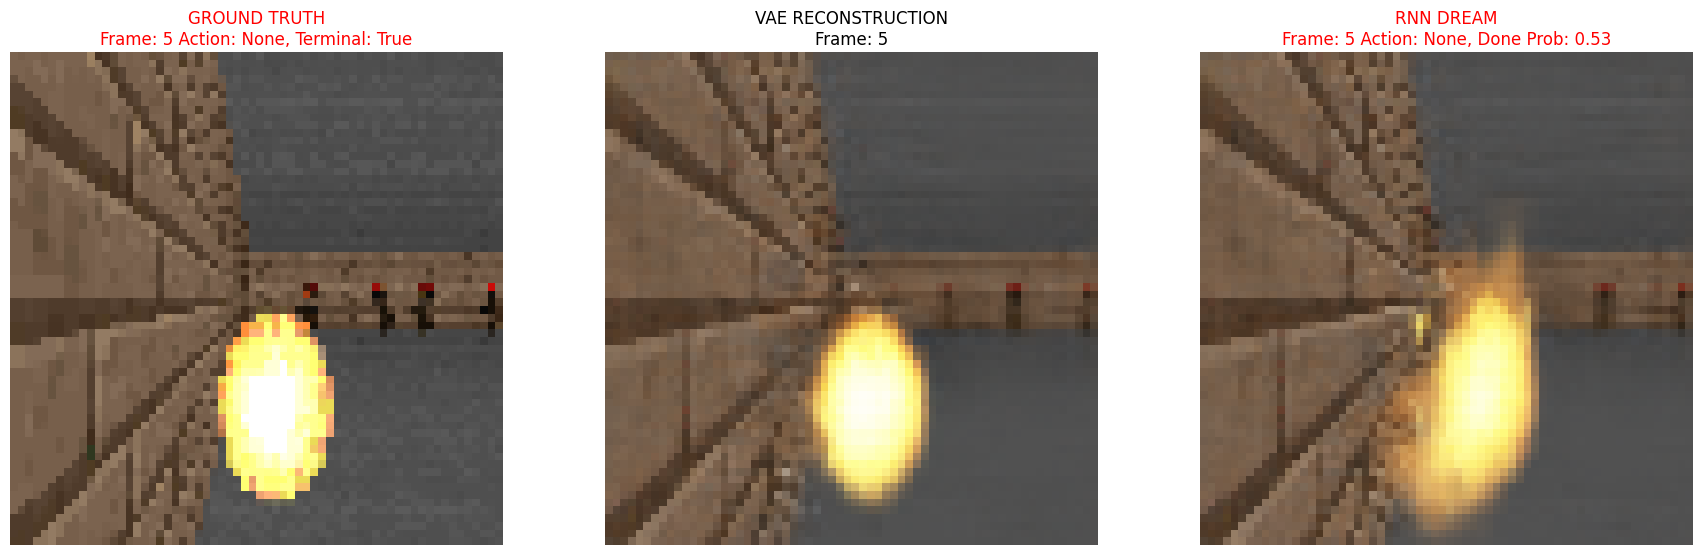

In [18]:
args.rnn_path = '../models/rnn/rnn.lat64.nl.1.h512.seq300.e100.bs128.latent64_vizdoom_1_32_2.5k.17-08.cpt.50.pt'
main(args)